# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

## The Paper

Please take some time to read through the paper and understand their approach, hypotheses and goals.

### What was the objective of the study?

Research the development of physical dependence and addiction disorders due to misuse of opioid analgesics. It is a major concern with pain therapeutics. They developed a mouse model of oxycodone exposure and subsequent withdrawal in the presence or absence of chronic neuropathic pain.

### What do the conditions mean?

#### oxy:
- mice got oxycodone once a day for 14 days (30 mg/kg)
- 21 days of spontaneous withdrawal
- tissue collected at end

#### sal:
- saline injections on same schedule as oxy
- then also tissue collected after 21 days of "withdrawal"
- vehicle control

### What do the genotypes mean?

-> ll mice are the same strain, but SNI and Sham are the surgical treatment

#### SNI:
- Spared Nerve Injury (SNI) on the left sciatic nerve
- two of three branches are tied off and cut
tibial nerve s left intact
- pain from touch was measured

#### Sham:
- same surgery but nerves left untouched
- control for effect of surgery and anaesthesia

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.

#### What would you do?
1. download runs from SRA
2. check read quality
3. align and count
4. run differential expression (separately for each brain region)
5. do gene ontology and pathway enrichment on the resulting gene lists

#### Which groups would you compare to each other?
A. SNI-Sal vs Sham-Sal (effect of pain alone) -> What does chronic pain alone do?\
B. Sham-Oxy vs Sham-Sal (opiod withdrawal without pain) -> What does withdrawal alone do?\
C. SNI-Oxy vs SNI-Sal (opiod withdrawal with pain) -> What does withdrawal do in pain?\
D. SNI-Oxy vs Sham-Sal (combined effect) \
E. SNI-Oxy vs Sham-Oxy (how chronic pain changes brain's state after opioid withdrawal) -> How does pain change the withdrawn state?

#### Expected outcome from each comparison:
A. moderate set of DEGs (differentially expressed gene) from chronic pain, involving neuroinflammation and synaptic plasticity genes\
B. withdrawal-related changes in the reward circuit, such as dopamine and synaptic signalling genes\
C. withdrawal changes that partly overlap with the Sham-Oxy comparison but are clearly different. This is the key comparison. The paper found only a limited overlap\
D. the largest number of DEGs
E. clear set of DEGs, bigger than SNI-Sal vs Sham-Sal

-> chronic pain changes how the reward circuit responds to opiod withdrawal at the transcipt level


## The Raw Data

Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results.

In [ ]:
# packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import raw data
raw_data = pd.read_excel("conditions_runs_oxy_project.xlsx")

# "x" columns -> one column each for condition and genotype
cond_cols = ["condition: Sal", "Condition: Oxy"]
geno_cols = ["Genotype: SNI", "Genotype: Sham"]
df = raw_data[raw_data["RNA-seq"] == "x"].copy()
df["condition"] = df[cond_cols].notna().idxmax(axis=1).str.split(": ").str[1]
df["genotype"] = df[geno_cols].notna().idxmax(axis=1).str.split(": ").str[1]

# remove unnecessary columns and sort by genotype, condition, and run
df = df[["Run", "genotype", "condition"]].sort_values(["genotype", "condition", "Run"]).reset_index(drop=True)
df

,Run,genotype,condition
0,SRR23195508,SNI,Oxy
1,SRR23195509,SNI,Oxy
2,SRR23195516,SNI,Oxy
3,SRR23195517,SNI,Oxy
4,SRR23195505,SNI,Sal
5,SRR23195510,SNI,Sal
6,SRR23195513,SNI,Sal
7,SRR23195518,SNI,Sal
8,SRR23195506,Sham,Oxy
9,SRR23195511,Sham,Oxy


#### 1. How many samples do you have per condition?

condition
Oxy    8
Sal    8
Name: count, dtype: int64


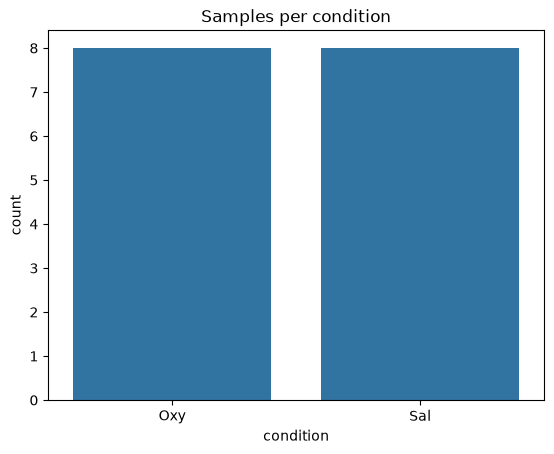

In [7]:
print(df["condition"].value_counts())
sns.countplot(data=df, x="condition")
plt.title("Samples per condition")
plt.show()

#### 2. How many samples do you have per genotype?

genotype
SNI     8
Sham    8
Name: count, dtype: int64


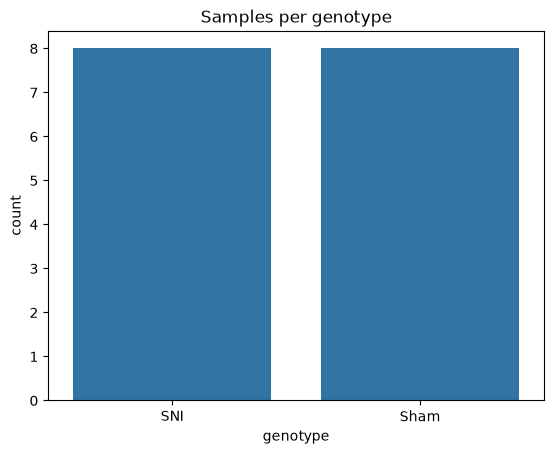

In [8]:
print(df["genotype"].value_counts())
sns.countplot(data=df, x="genotype")
plt.title("Samples per genotype")
plt.show()

#### 3. How often do you have each condition per genotype?

condition  Oxy  Sal
genotype           
SNI          4    4
Sham         4    4


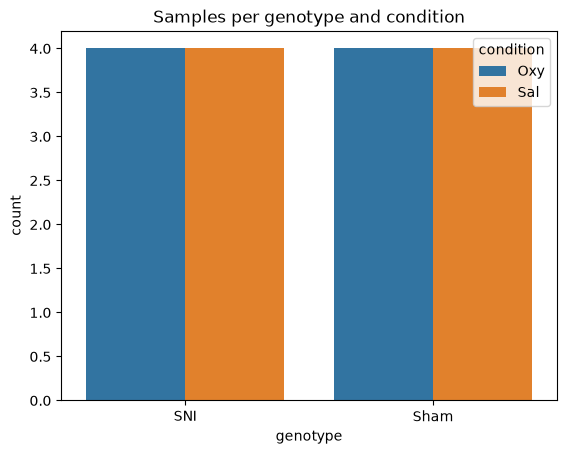

In [9]:
print(pd.crosstab(df["genotype"], df["condition"]))
sns.countplot(data=df, x="genotype", hue="condition")
plt.title("Samples per genotype and condition")
plt.show()

## The Bases

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

In [10]:
bases = pd.read_csv("base_counts.csv")
df = df.merge(bases, on="Run", how="left")
df = df.sort_values(["condition", "Bases"]).reset_index(drop=True)
df

,Run,genotype,condition,Bases
0,SRR23195516,SNI,Oxy,6203117700
1,SRR23195511,Sham,Oxy,6456390900
2,SRR23195517,SNI,Oxy,6863840400
3,SRR23195508,SNI,Oxy,6927786900
4,SRR23195519,Sham,Oxy,6996050100
5,SRR23195509,SNI,Oxy,7003550100
6,SRR23195514,Sham,Oxy,7226808600
7,SRR23195506,Sham,Oxy,7859530800
8,SRR23195505,SNI,Sal,6922564500
9,SRR23195510,SNI,Sal,7377388500


Then select the 2 smallest runs from your dataset... and download them from SRA (maybe an nf-core pipeline can help here?...)

In [11]:
# Pick the 2 smallest and write the ID list:
smallest = df.nsmallest(2, "Bases")
smallest["Run"].to_csv("ids.csv", index=False, header=False)
smallest

,Run,genotype,condition,Bases
0,SRR23195516,SNI,Oxy,6203117700
1,SRR23195511,Sham,Oxy,6456390900


In [ ]:
# Download with nf-core/fetchngs
!nextflow run nf-core/fetchngs -r 1.13.0 -profile docker --input ids.csv --outdir results


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/fetchngs` [angry_crick] revision: 955c892d80 [1.13.0]

WARN: Unrecognized config option 'manifest.diagram'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/fetchngs 1.13.0
------------------------------------------------------

Input/output options
  input              : ids.csv
  outdir             : results

Deprecated options
  trace_report_suffix: 2026-09-29_10-39-17

Core Nextflow options
  revision           : 1.13.0
  runName            : angry_crick
  containerEngine    : docker
  launchDir          : /data/cwmd/day_02
  workDir            : /data/cwmd/day_02/work
  projectDir         : /home/laurens/.nextflow/assets/.repos/nf-core/fetchngs/clo

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>

**Paper's pipeline:** TruSeq mRNA libraries, HiSeq 2000 -> HISAT2 -> HTSeq counts -> DESeq2 with a 2x2 factorial design
(`~ SNI + oxy + SNI:oxy`), DEGs at nominal p < 0.05 and |log2FC| > 0.5, then GO, IPA (pathways, upstream regulators),
RRHO (threshold free overlap of ranked lists) and CIBERSORTx deconvolution (NAc, Avey et al. scRNA-seq reference).

1. Get the data: all runs of PRJNA926667 with nf-core/fetchngs -> which also writes an nf-core/rnaseq samplesheet -> Check the GEO sample annotation for which brain region(s) our 16 runs cover
2. Preprocess: nf-core/rnaseq with `--aligner hisat2` to stay close to the paper (featureCounts replaces HTSeq) -> Check the MultiQC report 
3. Differential expression: nf-core/differentialabundance -> one contrast per comparison: SNI-Sal vs Sham-Sal, Sham-Oxy vs Sham-Sal, SNI-Oxy vs SNI-Sal, SNI-Oxy vs Sham-Sal, interaction SNI:oxy -> Use their cutoffs to compare against their numbers and also report padj < 0.05, since the nominal p is not corrected for ~20k tests
4. Interpretation: GO enrichment (g:Profiler / clusterProfiler) -> open substitute for upstream regulator prediction as IPA is commercial (e.g. ChEA3 or decoupler) -> check whether HDAC1/HDAC2 come up -> RRHO2 for the SNI vs Sham withdrawal overlap
5. Check reproduction: compare DEG counts per comparison (e.g. NAc: 1,457 SNI-Sal, 2,609 Sham-Oxy, 1,012 SNI-Oxy vs Sham-Sal) + the overlap between the withdrawal signatures + the top pathways

When you are done with this shout, so we can discuss the different ideas.